# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "hfc245fa"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[0.729 0.729 0.729 ... 1.192 1.192 1.192] [0.729 0.729 0.729 ... 1.192 1.192 1.192] [0.729 0.729 0.729 ... 1.192 1.192 1.192] [0.729 0.729 0.729 ... 1.192 1.192 1.192] [0.729 0.729 0.729 ... 1.192 1.192 1.192] [0.729 0.729 0.729 ... 1.192 1.192 1.192]] [[0.732 0.732 0.732 ... 1.185 1.185 1.185] [0.732 0.732 0.732 ... 1.185 1.185 1.185] [0.732 0.732 0.732 ... 1.185 1.185 1.185] [0.732 0.732 0.732 ... 1.185 1.185 1.185] [0.732 0.732 0.732 ... 1.185 1.185 1.185] [0.732 0.732 0.732 ... 1.185 1.185 1.185]] [[0.745 0.745 0.745 ... 1.202 1.202 1.202] [0.745 0.745 0.745 ... 1.202 1.202 1.202] [0.745 0.745 0.745 ... 1.202 1.202 1.202] [0.745 0.745 0.745 ... 1.202 1.202 1.202] [0.745 0.745 0.745 ... 1.202 1.202 1.202] [0.745 0.745 0.745 ... 1.202 1.202 1.202]] ... [[3.396 3.396 3.396 ... 4.147 4.111 4.075] [3.396 3.396 3.396 ... 4.146999999999999 4.111 4.075] [3.396 3.396 3.396 ... 4.099 4.111 4.075] [3.396 3.396 3.396 ... 4.134666666666667 4.104833333333334 4.075] [3.396 3.396 3.396 ... 4.140833333333333 4.111 4.075] [3.396 3.396 3.396 ... 4.147 4.111 4.075]] [[3.402 3.402 3.402 ... 4.173333333333333 4.159666666666666 4.146] [3.402 3.402 3.402 ... 4.173333333333333 4.159666666666666 4.146] [3.402 3.402 3.402 ... 4.148 4.159666666666666 4.146] [3.402 3.402 3.402 ... 4.203666666666667 4.174833333333334 4.146] [3.402 3.402 3.402 ... 4.1885 4.159666666666666 4.146] [3.402 3.402 3.402 ... 4.173333333333333 4.159666666666666 4.146]] [[3.385 3.385 3.385 ... 4.1770000000000005 4.183000000000001 4.189] [3.385 3.385 3.385 ... 4.177 4.183000000000001 4.189] [3.385 3.385 3.385 ... 4.12375 4.183 4.189] [3.385 3.385 3.385 ... 4.192666666666667 4.190833333333334 4.189] [3.385 3.385 3.385 ... 4.184833333333334 4.183 4.189] [3.385 3.385 3.385 ... 4.1770000000000005 4.183 4.189]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[0.729 0.729 0.729 ... 1.192 1.192 1.192] [0.729 0.729 0.729 ... 1.192 1.192 1.192] [0.729 0.729 0.729 ... 1.192 1.192 1.192] [0.729 0.729 0.729 ... 1.192 1.192 1.192] [0.729 0.729 0.729 ... 1.192 1.192 1.192] [0.729 0.729 0.729 ... 1.192 1.192 1.192]] [[0.732 0.732 0.732 ... 1.185 1.185 1.185] [0.732 0.732 0.732 ... 1.185 1.185 1.185] [0.732 0.732 0.732 ... 1.185 1.185 1.185] [0.732 0.732 0.732 ... 1.185 1.185 1.185] [0.732 0.732 0.732 ... 1.185 1.185 1.185] [0.732 0.732 0.732 ... 1.185 1.185 1.185]] [[0.745 0.745 0.745 ... 1.202 1.202 1.202] [0.745 0.745 0.745 ... 1.202 1.202 1.202] [0.745 0.745 0.745 ... 1.202 1.202 1.202] [0.745 0.745 0.745 ... 1.202 1.202 1.202] [0.745 0.745 0.745 ... 1.202 1.202 1.202] [0.745 0.745 0.745 ... 1.202 1.202 1.202]] ... [[3.396 3.396 3.396 ... 4.147 4.111 4.075] [3.396 3.396 3.396 ... 4.146999999999999 4.111 4.075] [3.396 3.396 3.396 ... 4.099 4.111 4.075] [3.396 3.396 3.396 ... 4.134666666666667 4.104833333333334 4.075] [3.396 3.396 3.396 ... 4.140833333333333 4.111 4.075] [3.396 3.396 3.396 ... 4.147 4.111 4.075]] [[3.402 3.402 3.402 ... 4.173333333333333 4.159666666666666 4.146] [3.402 3.402 3.402 ... 4.173333333333333 4.159666666666666 4.146] [3.402 3.402 3.402 ... 4.148 4.159666666666666 4.146] [3.402 3.402 3.402 ... 4.203666666666667 4.174833333333334 4.146] [3.402 3.402 3.402 ... 4.1885 4.159666666666666 4.146] [3.402 3.402 3.402 ... 4.173333333333333 4.159666666666666 4.146]] [[3.385 3.385 3.385 ... 4.1770000000000005 4.183000000000001 4.189] [3.385 3.385 3.385 ... 4.177 4.183000000000001 4.189] [3.385 3.385 3.385 ... 4.12375 4.183 4.189] [3.385 3.385 3.385 ... 4.192666666666667 4.190833333333334 4.189] [3.385 3.385 3.385 ... 4.184833333333334 4.183 4.189] [3.385 3.385 3.385 ... 4.1770000000000005 4.183 4.189]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'hfc245fa' (lon: 6, lat: 12, year: 16, month: 12)> Size: 111kB
<Quantity([[[[0.745      0.754      0.768      ... 0.898      0.907
    0.918     ]
   [0.924      0.93       0.955      ... 1.05       1.058
    1.047     ]
   [1.052      1.057      1.144      ... 1.176      1.183
    1.2       ]
   ...
   [2.988      3.006      3.042      ... 3.202      3.197
    3.181     ]
   [3.179      3.178      3.202      ... 3.309      3.306
    3.296     ]
   [3.295      3.299      3.305      ... 3.396      3.402
    3.385     ]]

  [[0.745      0.754      0.768      ... 0.898      0.907
    0.918     ]
   [0.924      0.93       0.955      ... 1.05       1.058
    1.047     ]
   [1.052      1.057      1.144      ... 1.176      1.183
    1.2       ]
...
   [3.78666667 3.779      3.79       ... 3.843      3.88433333
    3.967     ]
   [3.91666667 3.86233333 3.90833333 ... 3.95466667 4.017
    4.03266667]
   [4.02733333 4.04366667 4.03233333 ... 4.111      4.15966667
    4.183     ]]

  [[1.202      1.248      1.241      ... 1.318      1.415
    1.415     ]
   [1.382      1.339      1.352      ... 1.478      1.514
    1.522     ]
   [1.477      1.494      1.507      ... 1.635      1.654
    1.723     ]
   ...
   [3.795      3.788      3.788      ... 3.832      3.875
    3.98      ]
   [3.922      3.851      3.921      ... 3.928      4.011
    4.028     ]
   [4.023      4.036      4.02       ... 4.075      4.146
    4.189     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 128B 2008 2009 2010 2011 2012 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[0.745 0.754 0.768 ... 3.396 3.402 3.385] [0.745 0.754 0.768 ... 3.396 3.402 3.385] [0.745 0.754 0.768 ... 3.396 3.402 3.385] ... [1.202 1.248 1.241 ... 4.147 4.173333333333333 4.1770000000000005] [1.202 1.248 1.241 ... 4.111 4.159666666666666 4.183000000000001] [1.202 1.248 1.241 ... 4.075 4.146 4.189]] [[0.745 0.754 0.768 ... 3.396 3.402 3.385] [0.745 0.754 0.768 ... 3.396 3.402 3.385] [0.745 0.754 0.768 ... 3.396 3.402 3.385] ... [1.202 1.248 1.241 ... 4.146999999999999 4.173333333333333 4.177] [1.202 1.248 1.241 ... 4.111 4.159666666666666 4.183000000000001] [1.202 1.248 1.241 ... 4.075 4.146 4.189]] [[0.745 0.754 0.768 ... 3.396 3.402 3.385] [0.745 0.754 0.768 ... 3.396 3.402 3.385] [0.745 0.754 0.768 ... 3.396 3.402 3.385] ... [1.202 1.248 1.241 ... 4.099 4.148 4.12375] [1.202 1.248 1.241 ... 4.111 4.159666666666666 4.183] [1.202 1.248 1.241 ... 4.075 4.146 4.189]] [[0.745 0.754 0.768 ... 3.396 3.402 3.385] [0.745 0.754 0.768 ... 3.396 3.402 3.385] [0.745 0.754 0.768 ... 3.396 3.402 3.385] ... [1.202 1.248 1.241 ... 4.134666666666667 4.203666666666667 4.192666666666667] [1.202 1.248 1.241 ... 4.104833333333334 4.174833333333334 4.190833333333334] [1.202 1.248 1.241 ... 4.075 4.146 4.189]] [[0.745 0.754 0.768 ... 3.396 3.402 3.385] [0.745 0.754 0.768 ... 3.396 3.402 3.385] [0.745 0.754 0.768 ... 3.396 3.402 3.385] ... [1.202 1.248 1.241 ... 4.140833333333333 4.1885 4.184833333333334] [1.202 1.248 1.241 ... 4.111 4.159666666666666 4.183] [1.202 1.248 1.241 ... 4.075 4.146 4.189]] [[0.745 0.754 0.768 ... 3.396 3.402 3.385] [0.745 0.754 0.768 ... 3.396 3.402 3.385] [0.745 0.754 0.768 ... 3.396 3.402 3.385] ... [1.202 1.248 1.241 ... 4.147 4.173333333333333 4.1770000000000005] [1.202 1.248 1.241 ... 4.111 4.159666666666666 4.183] [1.202 1.248 1.241 ... 4.075 4.146 4.189]]]
Units,ppt


### Longitudinal-mean

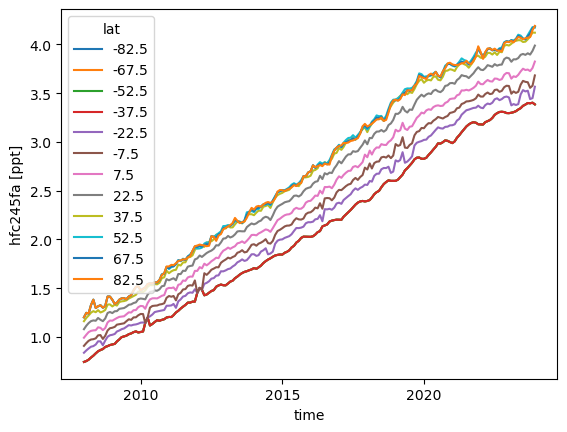

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

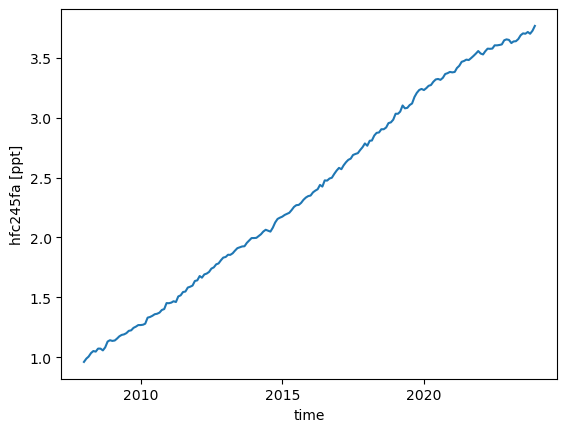

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

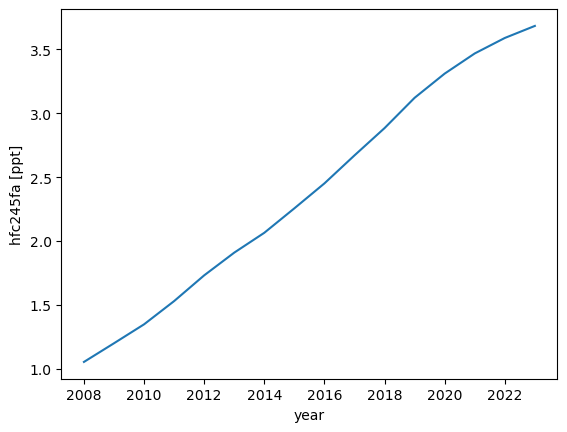

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 3kB
Dimensions:               (lat: 12, eof: 12, year: 16)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 128B 2008 2009 2010 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.3299 ... -7.726e-05
    principal-components  (year, eof) float64 2kB [] -0.6861 0.034 ... 4.798e-20

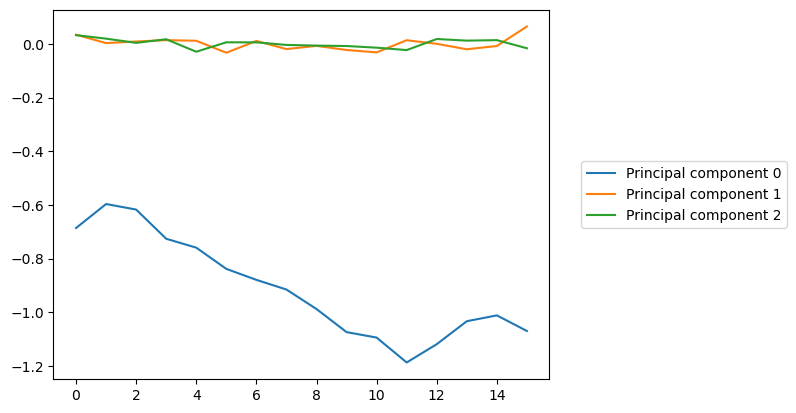

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

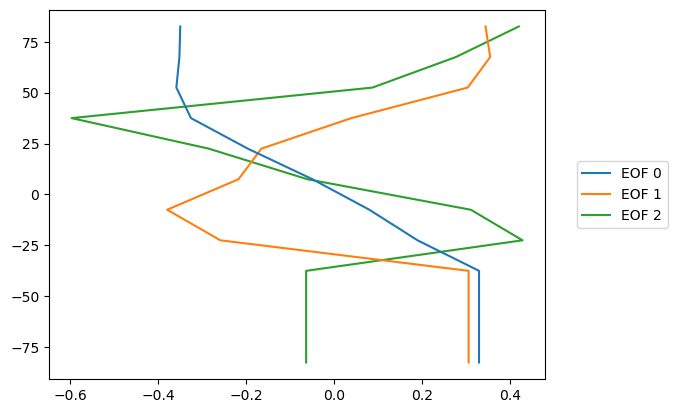

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

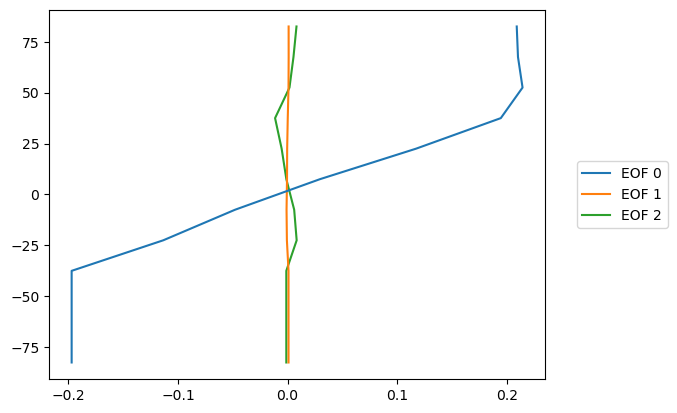

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.3299389704398631] [0.3299389704398632] [0.32993897043986326] [0.32993897043986326] [0.19000516573708215] [0.0803916613397187] [-0.04922264424905955] [-0.19620439490643182] [-0.32562569498966987] [-0.358838614811274] [-0.35186564141519044] [-0.34995801649258584]]
Units,ppt
Magnitude,[[-0.6861383666338255] [-0.596711976463498] [-0.6173040549155971] [-0.7260524110376003] [-0.7591399876608741] [-0.8381997025687964] [-0.8790913141756094] [-0.9150942083307597] [-0.9876995463272713] [-1.07365384809472] [-1.0939856848281404] [-1.1867226327982217] [-1.1186298506673504] [-1.033074865622134] [-1.0113558612397444] [-1.0694706372790412]]
Units,dimensionless


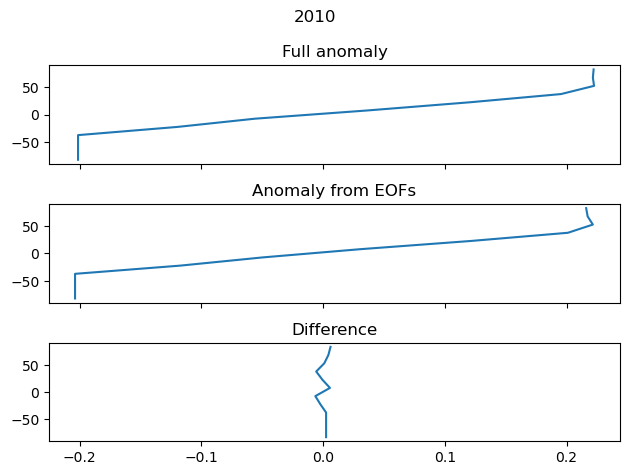

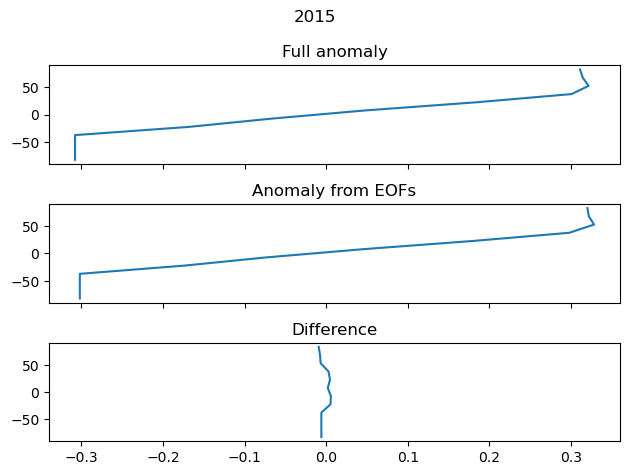

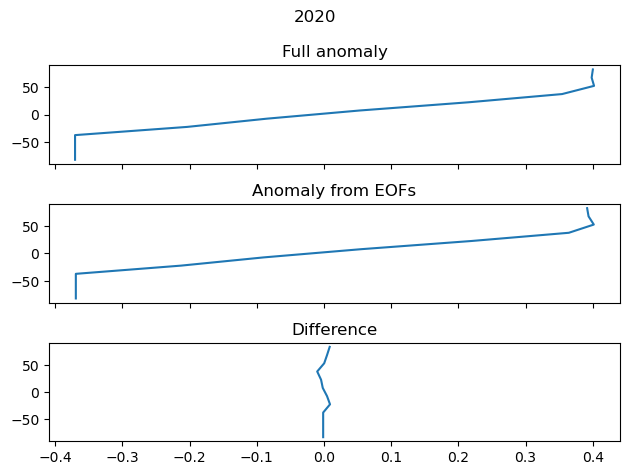

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 13597.87it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 19698.31it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 19530.15it/s]

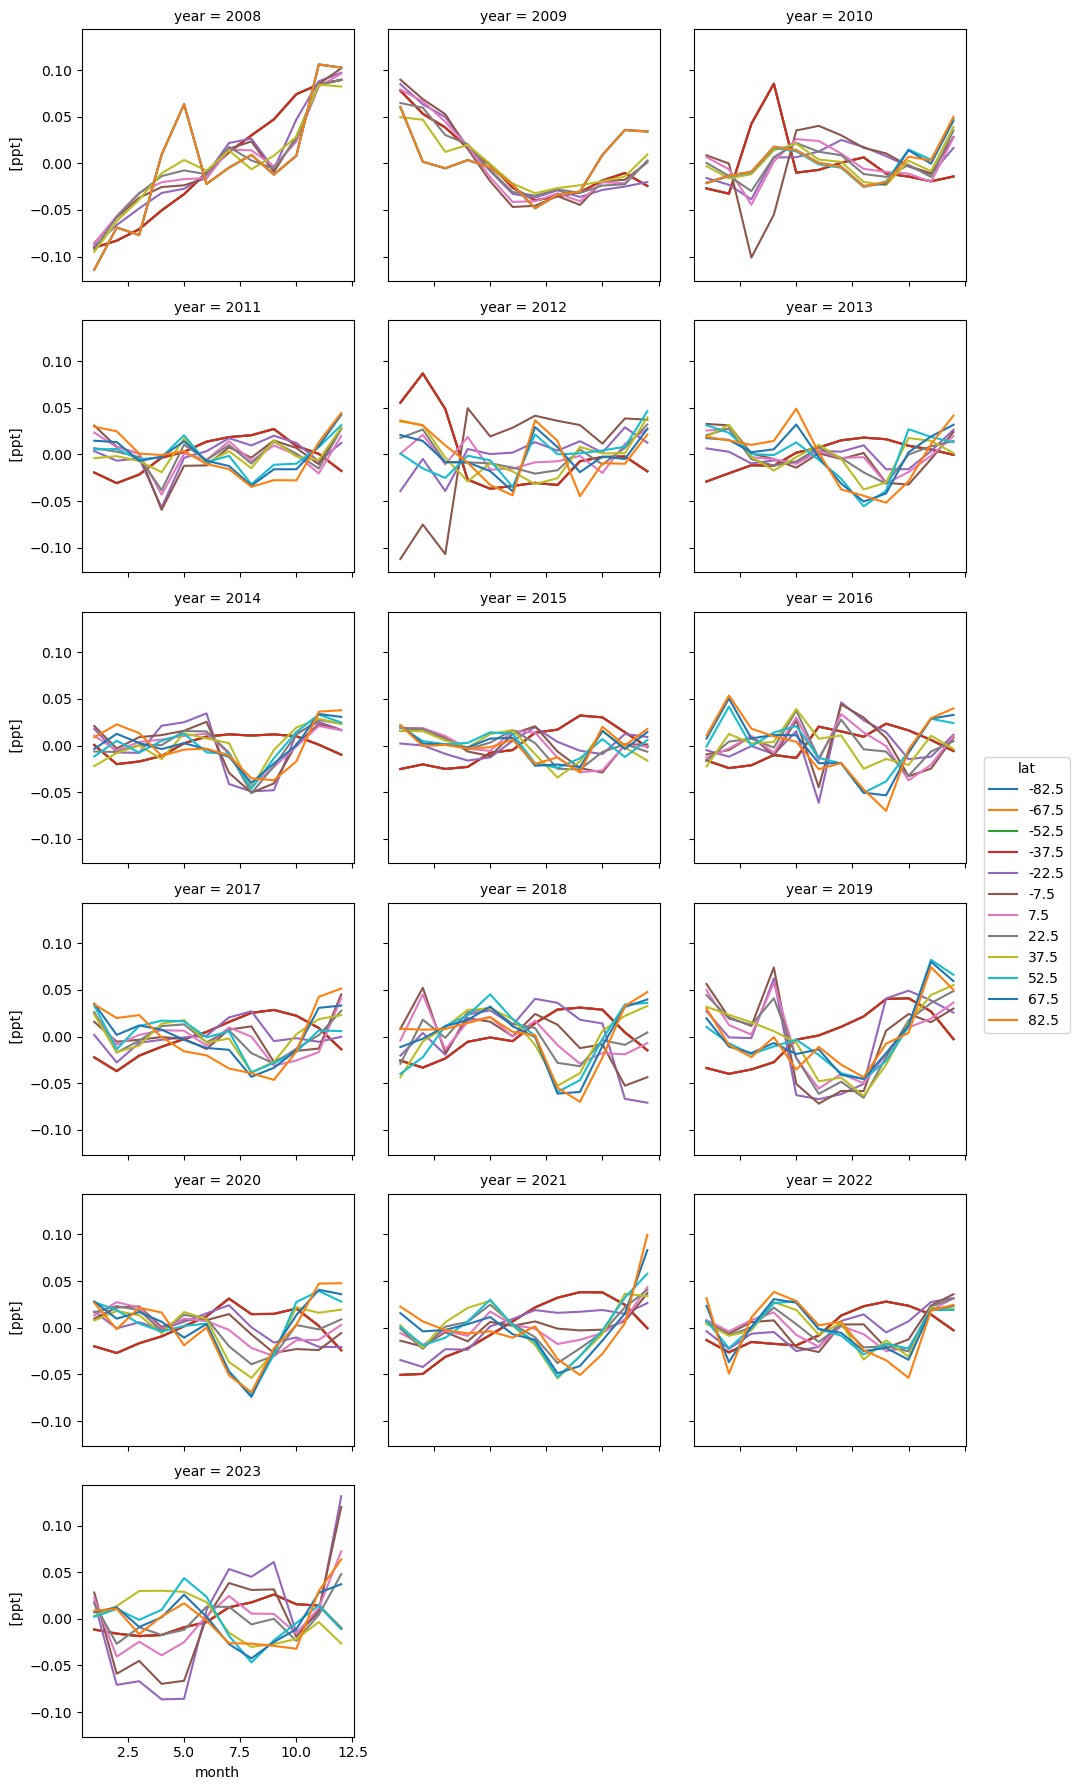

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

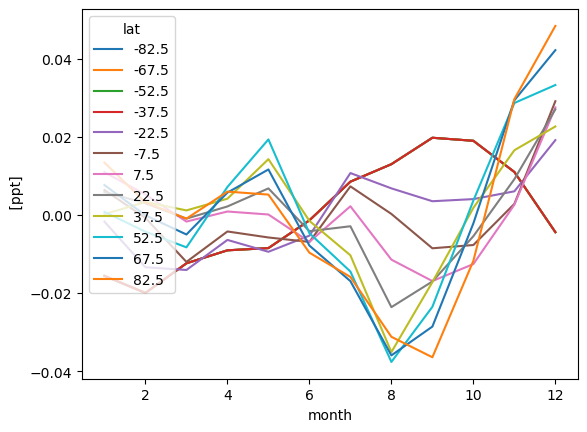

In [22]:
seasonality.plot.line(hue="lat")

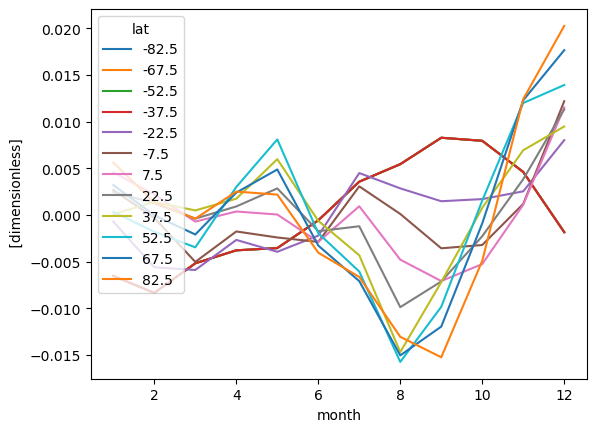

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[1.0531577507634842 1.19936952884641 1.3476157121237502 1.52960675446488 1.7311643102661882 1.9090454154532939 2.0644853935720064 2.255950440859553 2.4512805128626938 2.670605369167779 2.8842408973222295 3.121497999042053 3.3109186239904482 3.468779650437137 3.5900072985172433 3.684378881171407]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.3299389704398631] [0.3299389704398632] [0.32993897043986326] [0.32993897043986326] [0.19000516573708215] [0.0803916613397187] [-0.04922264424905955] [-0.19620439490643182] [-0.32562569498966987] [-0.358838614811274] [-0.35186564141519044] [-0.34995801649258584]]
Units,ppt
Magnitude,[[-0.6861383666338255] [-0.596711976463498] [-0.6173040549155971] [-0.7260524110376003] [-0.7591399876608741] [-0.8381997025687964] [-0.8790913141756094] [-0.9150942083307597] [-0.9876995463272713] [-1.07365384809472] [-1.0939856848281404] [-1.1867226327982217] [-1.1186298506673504] [-1.033074865622134] [-1.0113558612397444] [-1.0694706372790412]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.006525347240574602 -0.008346962850971064 -0.0051754017433344335 -0.003786894787548366 -0.0035485863936311848 -0.0005762014332728613 0.0035622229845346668 0.005435102692537958 0.008264093087190403 0.007938891970473108 0.004599531466441274 -0.00184047218242935] [-0.006525347240574602 -0.008346962850971064 -0.0051754017433344335 -0.003786894787548366 -0.0035485863936311848 -0.0005762014332728613 0.0035622229845346668 0.005435102692537958 0.008264093087190403 0.007938891970473108 0.004599531466441274 -0.00184047218242935] [-0.006525347240574602 -0.008346962850971064 -0.0051754017433344335 -0.003786894787548366 -0.0035485863936311848 -0.0005762014332728613 0.0035622229845346668 0.005435102692537958 0.008264093087190403 0.007938891970473108 0.004599531466441274 -0.00184047218242935] [-0.006525347240574602 -0.008346962850971064 -0.0051754017433344335 -0.003786894787548366 -0.0035485863936311848 -0.0005762014332728613 0.0035622229845346668 0.005435102692537958 0.008264093087190403 0.007938891970473108 0.004599531466441274 -0.00184047218242935] [-0.0007148530764811404 -0.005600283732545681 -0.0058902533518491226 -0.002672884510638743 -0.00394268343281772 -0.002214490313711867 0.0044848923693054 0.0028456693427752694 0.0014693662654793591 0.001697076979905199 0.0025305636964826797 0.008007904060274613] [0.002671115846739137 -0.0003161267249444448 -0.00502766589153639 -0.0017677105179909488 -0.0024112500394290817 -0.0028876013418088725 0.0030592150375083425 0.00010816061365742488 -0.0035690280292487012 -0.0032180864352963612 0.0011821664599408767 0.012176824642309687] [0.004570709736572815 0.0021876772599901365 -0.0007103450852647666 0.00036866842264595437 4.811586074640547e-05 -0.0028802878060784163 0.0009290529182139142 -0.004784842671870772 -0.007077094612129138 -0.005256169874106026 0.0010929005609926446 0.011511598490243299] [0.0024668639251366783 0.001250104898373655 -0.00039172374404094226 0.0009097845778839955 0.0028417994728651137 -0.0017370356959059527 -0.0012099537720740377 -0.009869575554322621 -0.00712259426771726 -0.002275453290218804 0.0038300191547315163 0.011307731945556827] [8.00553578035889e-05 0.0013934085830061907 0.00048520204397312685 0.0017397326933582978 0.005972347638565422 -0.0006345825737692088 -0.004319318539783078 -0.014684309211267383 -0.007194097781288865 0.0007612635012125734 0.006928449721411156 0.009471782195234663] [0.0003305934099612302 -0.0017965839407897953 -0.003468179229279443 0.0029958445782807025 0.008085576693941885 -0.001956448259701742 -0.006057487297408129 -0.0157336367761217 -0.009835816693728489 0.0015411544414715168 0.011985619364067484 0.013909299425833431] [0.0031969261827685088 -3.89714102988347e-05 -0.002091574191610693 0.0023918858110039223 0.004869944858764172 -0.0032773095788973506 -0.007085341423600138 -0.015034183938159354 -0.011950428828065901 -0.0008999579294936547 0.012278264268410641 0.017640703775409716] [0.0056029195098641835 0.0013469514898949676 -0.0003973849041992584 0.002500571542765301 0.002178722988093228 -0.004039948528687237 -0.006638205093445565 -0.013044674904538608 -0.015236599831936985 -0.0049110679917383935 0.012402291762443458 0.02023639208341488]]
Units,dimensionless
